# Activation plot

Plot for 2024 activation email

In [1]:
%load_ext jupyter_black
%load_ext autoreload
%autoreload 2

In [2]:
from datetime import datetime

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as ticker

from src.datasources import abn
from src.constants import *
from src.utils import shift_to_floodseason_corrected, FLOODSEASON_START
from utils import FLOODSEASON_ENDDAY

In [3]:
monitoring_df = abn.load_current_monitoring()

In [4]:
monitoring_df

,date,level
0,2024-10-27,552.0
1,2024-10-28,554.0
2,2024-10-29,554.0
3,2024-10-30,556.0
4,2024-10-31,558.0
...,...,...
84,2025-01-19,632.0
85,2025-01-20,634.0
86,2025-01-21,635.0
87,2025-01-22,636.0


In [5]:
THRESH = 580

In [6]:
level = abn.load_abn_niamey().reset_index()
level = level.rename(columns={"Date": "date", "Water Level (cm)": "level"})

In [7]:
level = pd.concat([level, monitoring_df])

In [8]:
level = shift_to_floodseason_corrected(level)
level = level[level["seasonyear"] >= 2005]
level.sort_values("date")

,date,level,Discharges (m3/s),year,dayofyear,dayofseason,seasonyear
152,2005-06-02,133.667,63.340,2005,153,2.0,2005
153,2005-06-03,147.000,86.667,2005,154,3.0,2005
154,2005-06-04,156.667,105.333,2005,155,4.0,2005
155,2005-06-05,181.000,157.467,2005,156,5.0,2005
156,2005-06-06,167.667,127.933,2005,157,6.0,2005
...,...,...,...,...,...,...,...
84,2025-01-19,632.000,NaN,2025,19,233.0,2024
85,2025-01-20,634.000,NaN,2025,20,234.0,2024
86,2025-01-21,635.000,NaN,2025,21,235.0,2024
87,2025-01-22,636.000,NaN,2025,22,236.0,2024


In [9]:
level.iloc[-20:]

,date,level,Discharges (m3/s),year,dayofyear,dayofseason,seasonyear
69,2025-01-04,620.0,NaN,2025,4,218.0,2024
70,2025-01-05,622.0,NaN,2025,5,219.0,2024
71,2025-01-06,623.0,NaN,2025,6,220.0,2024
72,2025-01-07,623.5,NaN,2025,7,221.0,2024
73,2025-01-08,623.0,NaN,2025,8,222.0,2024
74,2025-01-09,624.0,NaN,2025,9,223.0,2024
75,2025-01-10,625.5,NaN,2025,10,224.0,2024
76,2025-01-11,626.5,NaN,2025,11,225.0,2024
77,2025-01-12,626.0,NaN,2025,12,226.0,2024
78,2025-01-13,626.0,NaN,2025,13,227.0,2024


In [10]:
def set_plot_date(row):
    try:
        if row["date"].year == row["seasonyear"]:
            return datetime(1900, row["date"].month, row["date"].day)
        else:
            return datetime(1901, row["date"].month, row["date"].day)

    except Exception as e:
        print(e)
        print(row["date"])

In [11]:
level["plot_date"] = level.apply(set_plot_date, axis=1)

day is out of range for month
2008-02-29 00:00:00
day is out of range for month
2012-02-29 00:00:00
day is out of range for month
2016-02-29 00:00:00
day is out of range for month
2020-02-29 00:00:00


<Axes: xlabel='plot_date'>

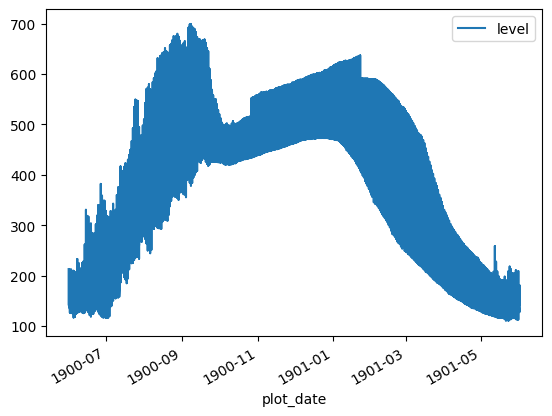

In [12]:
level.plot(x="plot_date", y="level")

In [13]:
level["date"].apply(lambda x: x.month).max()

12

In [14]:
FLOODSEASON_ENDDAY

153

In [15]:
gui_df = level[(level["dayofseason"] > FLOODSEASON_ENDDAY)]

In [16]:
gui_df[gui_df["level"] >= THRESH].groupby("seasonyear")["date"].min()

seasonyear
2018   2019-01-03
2020   2021-01-12
2024   2024-11-28
Name: date, dtype: datetime64[ns]

In [17]:
gui_df.loc[
    gui_df[gui_df["level"] >= THRESH].groupby("seasonyear")["level"].idxmax()
]

,date,level,Discharges (m3/s),year,dayofyear,dayofseason,seasonyear,plot_date
5133,2019-01-21,592.0,1848.0,2019,21,235.0,2018,1901-01-21
5860,2021-01-17,582.0,1780.0,2021,17,231.0,2020,1901-01-17
88,2025-01-23,637.0,NaN,2025,23,237.0,2024,1901-01-23


In [18]:
def custom_date_formatter(x, pos):
    date = mdates.num2date(x)  # Convert numeric value to date
    month_abbr = date.strftime(
        "%b"
    )  # Get abbreviated month name (e.g., "Jan", "Feb")
    day = date.day  # Get day of the month
    translated_month = FRENCH_MONTHS.get(
        month_abbr, month_abbr
    )  # Translate month
    return f"{day} {translated_month}"  # Format as "Translated Month Day"

Text(0.5, 1.0, 'Fleuve Niger à Niamey\nCrues guinéennes (depuis 2005)')

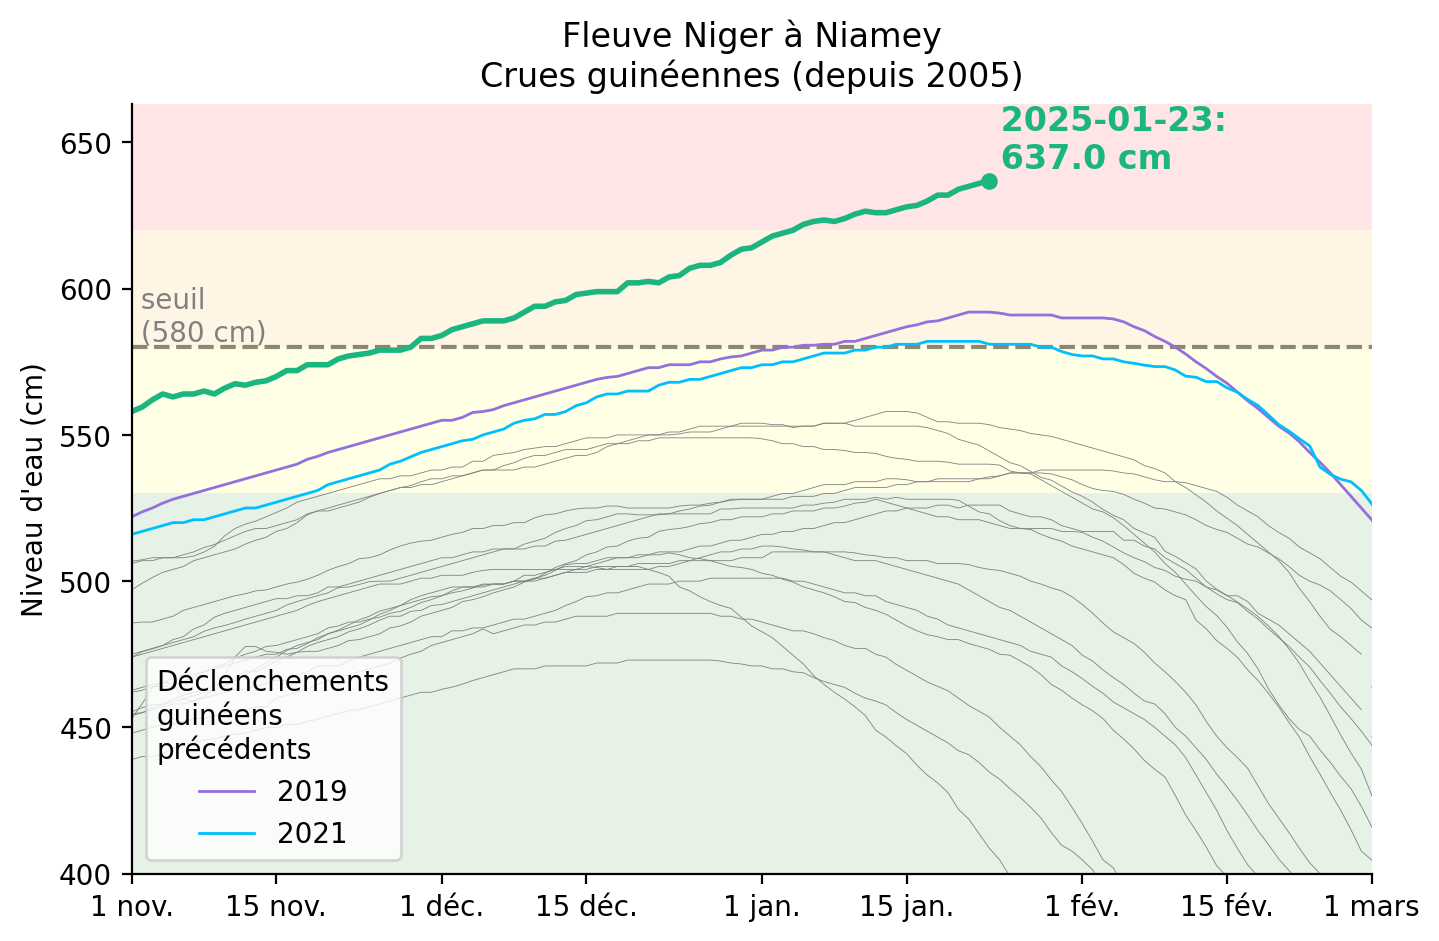

In [19]:
fig, ax = plt.subplots(dpi=200, figsize=(8, 5))

seasonyear_colors = {2018: "mediumpurple", 2020: "deepskyblue"}

for seasonyear in gui_df["seasonyear"].unique():
    dff = (
        gui_df[gui_df["seasonyear"] == seasonyear]
        .copy()
        .dropna(subset=["level"])
    )
    if seasonyear == 2024:
        color = CHD_GREEN
        label = None
        width = 2
    elif seasonyear in seasonyear_colors:
        color = seasonyear_colors.get(seasonyear)
        label = dff[dff["level"] >= THRESH]["date"].min().year
        width = 1
    else:
        color = "grey"
        label = None
        width = 0.3
    ax.plot(
        dff["plot_date"],
        dff["level"],
        color=color,
        label=label,
        linewidth=width,
    )

latest_row = gui_df.loc[gui_df["date"].idxmax()]
ax.annotate(
    f' {latest_row["date"].date()}:\n {latest_row["level"]} cm',
    (latest_row["plot_date"], latest_row["level"] + 4),
    color=CHD_GREEN,
    fontsize=12,
    fontweight="bold",
)
ax.plot(
    latest_row["plot_date"],
    latest_row["level"],
    color=CHD_GREEN,
    marker=".",
    markersize=10,
)

ax.legend(title="Déclenchements\nguinéens\nprécédents", loc="lower left")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_ylabel("Niveau d'eau (cm)")
ax.set_xlim(left=datetime(1900, 11, 1), right=datetime(1901, 3, 1))
ax.set_ylim(bottom=400)

ax.axhspan(0, 530, facecolor="green", alpha=0.1)
ax.axhspan(530, 580, facecolor="yellow", alpha=0.1)
ax.axhspan(580, 620, facecolor="orange", alpha=0.1)
ax.axhspan(620, 700, facecolor="red", alpha=0.1)
ax.axhline(580, color="gray", linestyle="--", zorder=-1)
ax.annotate(
    " seuil\n (580 cm)",
    (datetime(1900, 11, 1), 580),
    color="gray",
    ha="left",
    va="bottom",
)

# French dates formatting
ax.xaxis.set_major_formatter(ticker.FuncFormatter(custom_date_formatter))

ax.set_title("Fleuve Niger à Niamey\nCrues guinéennes (depuis 2005)")

In [19]:
gui_df.loc[gui_df["level"].idxmax()]

date                 2024-12-13 00:00:00
level                              596.0
Discharges (m3/s)                    NaN
year                                2024
dayofyear                            348
dayofseason                        197.0
seasonyear                          2024
plot_date            1900-12-13 00:00:00
Name: 47, dtype: object